# The macro-anchor as a stochastic short-rate model — affine curves, closed-form distributions

This notebook takes the project's distinctive idea to its mathematically natural home. The
data said: the **10y level barely mean-reverts** (the naive reversion test failed), but the
**front end does** — policy drags the short rate toward neutral. So instead of imposing an
anchor on the 10y, we put it **where the reversion actually lives**: as the **central
tendency of the instantaneous short rate**, and let the whole curve — and the fair value of
every tenor — **emerge** from expectations + convexity via exponential-decay loadings.

Three models of $dr_t$, all estimated under the **physical measure P** (time series), never
calibrated to today's curve:

| Model | Dynamics | Transition distribution | Role |
|---|---|---|---|
| **OU / Vasicek** | $dr=\kappa(\theta-r)\,dt+\sigma\,dW$ | **Normal**, closed form | baseline, constant $\theta$ |
| **CIR** | $dr=\kappa(\theta-r)\,dt+\sigma\sqrt{r}\,dW$ | **Non-central $\chi^2$**, closed form | level-dependent vol, $r\ge0$ |
| **Hull-White(anchor)** | $dr=\kappa(\theta_t-r)\,dt+\sigma\,dW$, $\ \theta_t=r^*_t+\pi_{e,t}$ | Normal | **the thesis as a process** |

**The P-vs-Q point (why this isn't circular).** In pricing you calibrate to today's curve
and recover **risk-neutral (Q)** parameters — comparing that model curve to the market gives
~zero *by construction*. Here we do the opposite: estimate the **physical (P)** dynamics from
the short-rate time series, build the **pure-expectations curve** (expectations + convexity,
zero price of risk), and the wedge to the observed curve **is the model-implied term
premium**, tenor by tenor:
$$TP(\tau,t)=y_{obs}(\tau,t)-y_{PE}(\tau,t).$$
In the long-sample notebook the term premium was an *input block* of the anchor; here it is
an **output**. And because the transition laws are closed-form, we get not just expected
tenors but their **entire predictive distribution** — moments and tails — which powers the
distributional layer (PIT calibration, variance forecasting, z-sizing, tail throttle,
OU-vs-CIR ZLB disagreement).

> ⚠️ **Honest expectations.** One-factor models cannot fit the real curve (your PCA said
> 73/20/5 — three factors), so part of each "TP" is misfit; the model TP may be the slope in
> disguise (we test exactly that); $\hat\kappa$ is biased up near unit roots; and OOS
> predictability will likely stay fragile, as everywhere in this literature. The
> distributional layer is where closed forms have their best shot: **variance is more
> predictable than the mean.**

## Implementation, structured

**Estimation (all physical-measure, all cheap enough to run expanding).**
- *OU*: exact discretisation is an AR(1): $r_{t+\Delta}=\theta(1-a)+a\,r_t+\varepsilon$,
  $a=e^{-\kappa\Delta}$ → OLS gives $\kappa=-12\ln a$, $\theta$, and $\sigma^2=\widehat{Var}(\varepsilon)\cdot 2\kappa/(1-a^2)$.
- *CIR*: weighted least squares on $\Delta r = \kappa\theta\Delta-\kappa\Delta r+e$ with
  weights $1/\sqrt r$ (QML via the exact conditional moments), refined by **exact non-central-$\chi^2$
  maximum likelihood** when `scipy` is available. The **Feller condition** $2\kappa\theta\ge\sigma^2$ is reported, not hidden.
- *HW(anchor)*: regress $\Delta r$ on the **gap to the anchor** $(\theta_t-r_t)$ — the
  project's original policy-gap regression, now as a parameter estimator: the slope *is*
  $\kappa\Delta$. $\theta_t=r^*_t+\pi_{e,t}$ uses the same anchor blocks as before (HLW or
  slow-real-rate proxy for $r^*$; CPI-trend EWMA for $\pi_e$), **without** a TP block.

**Pure-expectations curves (closed form).** Vasicek/HW:
$B(\tau)=\frac{1-e^{-\kappa\tau}}{\kappa}$, $\ \ln A(\tau)=(\theta-\frac{\sigma^2}{2\kappa^2})(B-\tau)-\frac{\sigma^2B^2}{4\kappa}$,
$\ y_{PE}=\frac{-\ln A+B\,r_t}{\tau}$ — the exponential-decay loading you described. CIR has
its own $A,B$ with $\gamma=\sqrt{\kappa^2+2\sigma^2}$. For HW the moving $\theta_t$ is held at
its current value over the horizon (a random-walk forecast of a slow anchor — stated, not
hidden), which makes the formula exact and transparent.

**No-look-ahead protocol.** Every downstream signal (TP, expected returns, variances, PIT)
uses **expanding-window parameters** re-estimated at each month $t$ from data $\le t$
(burn-in 120m); predictive tests refit forecasting regressions on past-only windows; trading
signals are lagged one month. Full-sample estimates are shown once, for description only.

**What each section delivers.** **A** parameters, half-lives, Feller, $\kappa$-bias caveat,
expanding paths (incl. the picture that *is* the thesis: $\theta_{HW}$ = moving anchor vs the
OU constant). **B** per-tenor model TP for all three models + the honesty checks
(corr with slope; corr with **Kim–Wright** where it overlaps). **C** the five-test battery on
the model TP: per-tenor Newey–West, basket regression, OOS-$R^2$ horse-race vs slope,
Fama–Bliss, the legacy 10y anchor gap, and slope+TP. **D1** PIT calibration of the 12m
short-rate distribution (OU vs CIR), the **variance-forecast race** (CIR level-dependent vol
vs trailing realized), convexity: belly-vs-wings by model-variance quintile. **D2**
**distribution-aware sizing**: closed-form $E[rx]$ and $SD[rx]$ → z-sized duration vs static /
sign / linear, a **tail throttle** on $P(rx<-5\%)$, and the OU-vs-CIR **lower-tail
disagreement** as a ZLB regime flag.

In [14]:
# ===== Data layer: FRED (pdr + CSV fallback), GSW zero-coupon curve, term premium, r* =====
import numpy as np, pandas as pd, warnings, io, urllib.request
import matplotlib.pyplot as plt
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({"figure.dpi":110,"font.size":9,"axes.grid":True,"grid.alpha":0.3})
START="1961-01-01"; END=str(pd.Timestamp.today().date())

def fred_series(ids, start=START, end=END):
    """FRED via pandas_datareader, with a direct fredgraph-CSV fallback."""
    ids = ids if isinstance(ids, list) else [ids]
    try:
        import pandas_datareader.data as web
        df = web.DataReader(ids, "fred", start, end)
        if df is not None and len(df.dropna(how="all")): return df
    except Exception as e:
        warnings.warn(f"pandas_datareader failed ({e}); using fredgraph CSV")
    out = {}
    for sid in ids:
        try:
            u = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}"
            d = pd.read_csv(u); d.columns = ["date","val"]; d["date"] = pd.to_datetime(d["date"])
            out[sid] = pd.to_numeric(d.set_index("date")["val"], errors="coerce")
        except Exception as e:
            warnings.warn(f"FRED CSV failed for {sid}: {e}")
    return pd.DataFrame(out) if out else None

def fetch_gsw():
    """Gurkaynak-Sack-Wright zero-coupon yields (Fed 'feds200628'), 1961-. Monthly SVENYxx in %."""
    url = "https://www.federalreserve.gov/data/yield-curve-tables/feds200628.csv"
    raw = urllib.request.urlopen(url, timeout=90).read().decode("utf-8","replace")
    lines = raw.splitlines()
    hdr = next(i for i,l in enumerate(lines) if l.lower().startswith("date,"))
    df = pd.read_csv(io.StringIO("\n".join(lines[hdr:])))
    df.columns = [c.strip() for c in df.columns]; dc = df.columns[0]
    df[dc] = pd.to_datetime(df[dc]); df = df.set_index(dc).sort_index()
    cols = [c for c in df.columns if c.upper().startswith("SVENY") and c[5:].strip().isdigit()]
    return df[cols].apply(pd.to_numeric, errors="coerce").resample("ME").last()

def fetch_tp():
    """10y term premium: ACM if on FRED, else Kim-Wright (THREEFYTP10). -> (Series decimal, name) or (None,None)."""
    for sid in ["ACMTP10","THREEFYTP10"]:
        try:
            d = fred_series([sid])
            if d is not None and sid in d and d[sid].notna().sum() > 50:
                s = (d[sid].resample("ME").last())/100.0; s.name = sid; return s, sid
        except Exception:
            pass
    return None, None

def fetch_hlw():
    """Best-effort HLW r* (NY Fed CSV). -> (Series decimal, src) or (None,None) so the caller uses a proxy."""
    urls = ["https://www.newyorkfed.org/medialibrary/media/research/policy/rstar/Holston_Laubach_Williams_current_estimates.csv"]
    for u in urls:
        try:
            df = pd.read_csv(u)
            dcol = [c for c in df.columns if "date" in c.lower()][0]
            rcands = [c for c in df.columns if "rstar" in c.lower()]
            rcol = ([c for c in rcands if "us" in c.lower()] or rcands)[0]
            s = pd.Series(pd.to_numeric(df[rcol], errors="coerce").values, index=pd.to_datetime(df[dcol])).dropna()
            s = (s/100.0 if s.median() > 1 else s).resample("ME").last().interpolate()
            if len(s) > 40: return s, "HLW (NY Fed)"
        except Exception:
            pass
    return None, None


In [2]:
# ===== Fetch the curve / short rate / CPI / term premium / r*, align to one monthly index =====
MATS_L = [1,2,3,5,7,10]
try:
    G = fetch_gsw(); need = [f"SVENY{m:02d}" for m in MATS_L]
    if G is None or any(c not in G.columns for c in need): raise RuntimeError("GSW columns missing")
    curve = G[need]/100.0; curve.columns = MATS_L
    CURVE_SRC = "GSW zero-coupon (Fed feds200628), 1961-"
except Exception as e:
    warnings.warn(f"GSW unavailable ({e}); falling back to FRED constant-maturity GS-series")
    ids = {1:"GS1",2:"GS2",3:"GS3",5:"GS5",7:"GS7",10:"GS10"}
    fr = fred_series(list(ids.values()))
    curve = pd.DataFrame({m: fr[ids[m]] for m in MATS_L})/100.0
    curve.index = pd.to_datetime(curve.index); curve = curve.resample("ME").last()
    CURVE_SRC = "FRED constant-maturity (GS1..GS10), ~1962-"

sh = fred_series(["TB3MS"]); short_s = (sh["TB3MS"].resample("ME").last())/100.0   # 3m bill, 1934-
cp = fred_series(["CPIAUCSL"]); cpi_s = cp["CPIAUCSL"].resample("ME").last()         # CPI, 1947-
tp_series, tp_name = fetch_tp(); hlw, hlw_src = fetch_hlw()

idx = curve.dropna().index.intersection(short_s.dropna().index).intersection(cpi_s.dropna().index)
dates = idx[idx >= curve.dropna().index[0]]
Y      = curve.reindex(dates).interpolate().to_numpy()
short  = short_s.reindex(dates).interpolate().to_numpy()
cpi_idx= cpi_s.reindex(dates).interpolate().to_numpy()
if tp_series is not None: tp_series = tp_series.reindex(dates)
if hlw is not None:       hlw = hlw.reindex(dates)
print(f"Assembled {len(dates)} months: {dates[0].date()} -> {dates[-1].date()}  | curve: {CURVE_SRC}")
print(f"  term premium: {tp_name or 'constant fallback'} | r*: {hlw_src or 'proxy fallback'}")


/tmp/ipykernel_5109/753382464.py:9: UserWarning: GSW unavailable (HTTP Error 403: Forbidden); falling back to FRED constant-maturity GS-series
  warnings.warn(f"GSW unavailable ({e}); falling back to FRED constant-maturity GS-series")
/tmp/ipykernel_5109/2759763444.py:16: UserWarning: pandas_datareader failed (Unable to read URL: https://fred.stlouisfed.org/graph/fredgraph.csv?id=ACMTP10
Response Text:
b'<!DOCTYPE html>\r\n<html lang="en">\r\n<head>\r\n    <meta charset="utf-8">\r\n    <meta http-equiv="X-UA-Compatible" content="IE=edge">\r\n    <meta name="viewport" content="width=device-width, initial-scale=1">\r\n    <title>Error - St. Louis Fed</title>\r\n    <meta name="description" content="">\r\n    <meta name="keywords" content="">    \r\n    <link rel="stylesheet" type="text/css" href="/assets/bootstrap/dist/css/bootstrap.min.css">\r\n    <link rel="stylesheet" type="text/css" href="/css/home.min.css?1553087253">\r\n    <link rel="stylesheet" type="text/css" href="/assets/font

Assembled 599 months: 1976-06-30 -> 2026-05-31  | curve: FRED constant-maturity (GS1..GS10), ~1962-
  term premium: THREEFYTP10 | r*: proxy fallback


SHORT-RATE ANCHOR  theta(t) = r* + pi_e
  pi_e : EWMA of trailing YoY CPI (hl=36m, Cieslak-Povala)
  r*   : proxy: EWMA real short (hl=120m)
  today: r* -0.28% + pi 3.35% = 3.07%   | 3M rate 3.60%


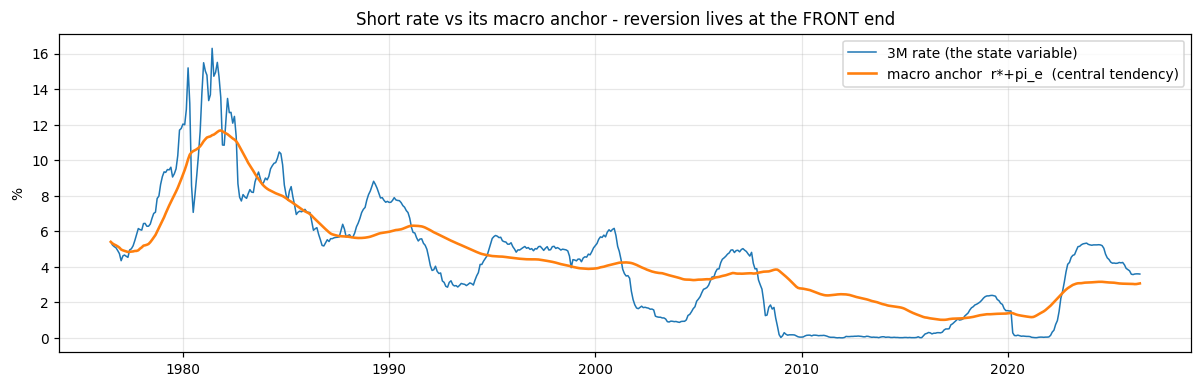

In [3]:
# ===== Short-rate macro anchor: theta(t) = r*(t) + pi_e(t)  (NO term premium here) =====
# The anchor is the CENTRAL TENDENCY of the short-rate process. The term premium is an
# OUTPUT of this notebook (observed curve minus model expectations), not an input.
import matplotlib.pyplot as plt
PI_HL=36; RSTAR_HL=120
cpi_yoy=pd.Series(cpi_idx,index=dates).pct_change(12)
pi_trend=cpi_yoy.ewm(halflife=PI_HL).mean().bfill()
short_s=pd.Series(short,index=dates)
if hlw is not None:
    rstar=pd.Series(hlw,index=dates).reindex(dates).interpolate().ffill().bfill(); rstar_src="HLW (NY Fed)"
else:
    rstar=(short_s-pi_trend).ewm(halflife=RSTAR_HL).mean().bfill(); rstar_src=f"proxy: EWMA real short (hl={RSTAR_HL}m)"
anchor_sr=(rstar+pi_trend).to_numpy()
r=np.asarray(short,float); Tn=len(r); DT=1/12
print("SHORT-RATE ANCHOR  theta(t) = r* + pi_e")
print("  pi_e :", f"EWMA of trailing YoY CPI (hl={PI_HL}m, Cieslak-Povala)")
print("  r*   :", rstar_src)
print(f"  today: r* {rstar.iloc[-1]*100:.2f}% + pi {pi_trend.iloc[-1]*100:.2f}% = {anchor_sr[-1]*100:.2f}%   | 3M rate {r[-1]*100:.2f}%")
plt.figure(figsize=(11,3.6))
plt.plot(dates,r*100,lw=1.0,label="3M rate (the state variable)")
plt.plot(dates,anchor_sr*100,lw=1.7,label="macro anchor  r*+pi_e  (central tendency)")
plt.ylabel("%"); plt.legend(); plt.title("Short rate vs its macro anchor - reversion lives at the FRONT end")
plt.tight_layout(); plt.show()


FULL-SAMPLE PHYSICAL-MEASURE ESTIMATES (monthly data, annualised params)
  OU/Vasicek : kappa 0.094 (half-life   88.8m) | theta  3.87% | sigma 1.49%
  CIR        : kappa 0.030 (half-life  274.3m) | theta  3.06% | sigma 0.058  | Feller 2kt=0.0019 vs s2=0.0034 -> VIOLATED (touches zero)
  HW(anchor) : kappa 0.175 (half-life   47.5m) toward r*+pi_e | sigma 1.48% | gap-slope t-stat 1.37
  caveats: AR-based kappa is biased UP in short samples (near unit root); CIR sigma via QML moments.
  CIR exact NCX2 ML refit: kappa 0.053 | theta 3.57% | sigma 0.061


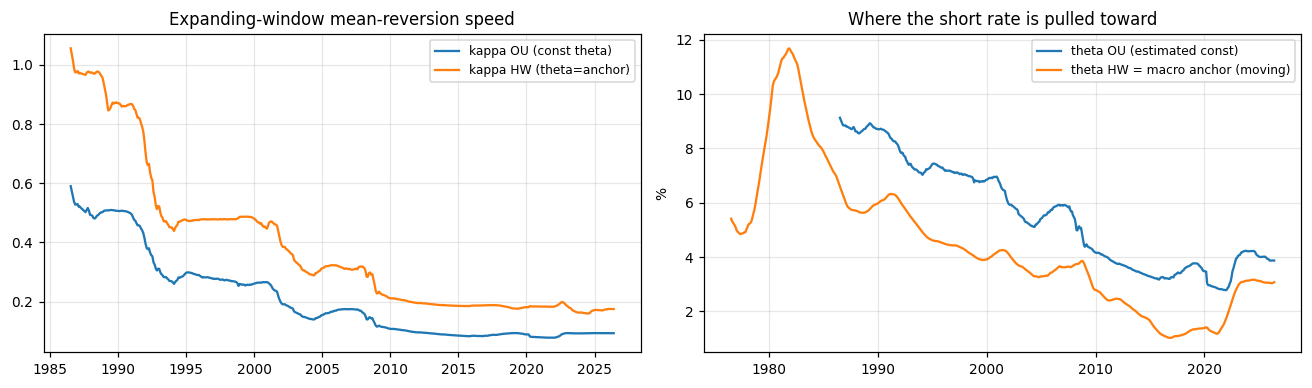

In [4]:
# ===== SECTION A: estimate the three short-rate models under the PHYSICAL measure =====
DTm=1/12; MINW=120
def fit_ou(rw):
    x=rw[:-1]; yv=rw[1:]; X=np.column_stack([np.ones(len(x)),x])
    c,b=np.linalg.lstsq(X,yv,rcond=None)[0]
    b=float(np.clip(b,1e-6,0.999999)); k=-12*np.log(b); th=float(c/(1-b))
    e=yv-(c+b*x); s2=float(np.var(e))*2*k/max(1-b*b,1e-10)
    return k,th,np.sqrt(max(s2,1e-10))
def fit_cir(rw):
    x=np.maximum(rw[:-1],1e-4); d=rw[1:]-rw[:-1]; w=1/np.sqrt(x)
    X=np.column_stack([np.ones(len(x))*w, x*w]); yv=d*w
    b0,b1=np.linalg.lstsq(X,yv,rcond=None)[0]
    k=float(np.clip(-b1*12,1e-4,20)); th=float(np.clip(b0*12/k,1e-4,0.5))
    e=d-(b0+b1*x); s2=float(np.mean(e*e/(x*DTm)))
    return k,th,np.sqrt(max(s2,1e-10))
def fit_hw(rw,anc):
    g=anc[:len(rw)-1]-rw[:-1]; d=rw[1:]-rw[:-1]
    X=np.column_stack([np.ones(len(g)),g]); a0,sl=np.linalg.lstsq(X,d,rcond=None)[0]
    e=d-(a0+sl*g); seb=np.sqrt(np.sum(e*e)/(len(g)-2)/np.sum((g-g.mean())**2))
    k=float(np.clip(sl*12,1e-4,20)); s=float(np.std(e))*np.sqrt(12)
    return k,s,float(sl/seb)
kOU,thOU,sOU=fit_ou(r); kC,thC,sC=fit_cir(r); kHW,sHW,tHW=fit_hw(r,anchor_sr)
print("FULL-SAMPLE PHYSICAL-MEASURE ESTIMATES (monthly data, annualised params)")
print(f"  OU/Vasicek : kappa {kOU:5.3f} (half-life {np.log(2)/kOU*12:6.1f}m) | theta {thOU*100:5.2f}% | sigma {sOU*100:4.2f}%")
print(f"  CIR        : kappa {kC:5.3f} (half-life {np.log(2)/kC*12:6.1f}m) | theta {thC*100:5.2f}% | sigma {sC:5.3f}  | Feller 2kt={2*kC*thC:.4f} vs s2={sC**2:.4f} -> {'OK' if 2*kC*thC>=sC**2 else 'VIOLATED (touches zero)'}")
print(f"  HW(anchor) : kappa {kHW:5.3f} (half-life {np.log(2)/kHW*12:6.1f}m) toward r*+pi_e | sigma {sHW*100:4.2f}% | gap-slope t-stat {tHW:.2f}")
print("  caveats: AR-based kappa is biased UP in short samples (near unit root); CIR sigma via QML moments.")
try:
    from scipy.stats import ncx2
    from scipy.optimize import minimize
    def cir_nll(p):
        k,th,s=p
        if k<=1e-4 or th<=1e-4 or s<=1e-4: return 1e9
        c=2*k/(s*s*(1-np.exp(-k*DTm))); df=4*k*th/(s*s); nc=2*c*np.maximum(r[:-1],1e-6)*np.exp(-k*DTm)
        ll=ncx2.logpdf(2*c*np.maximum(r[1:],1e-6),df,nc)+np.log(2*c)
        return -np.nansum(ll)
    res=minimize(cir_nll,[kC,thC,sC],method="Nelder-Mead",options={"maxiter":400,"xatol":1e-5,"fatol":1e-3})
    if res.success or res.fun<cir_nll([kC,thC,sC]):
        kC,thC,sC=[float(v) for v in res.x]
        print(f"  CIR exact NCX2 ML refit: kappa {kC:.3f} | theta {thC*100:.2f}% | sigma {sC:.3f}")
    HAVE_SCIPY=True
except Exception as e:
    HAVE_SCIPY=False; print("  (scipy unavailable -> CIR stays at QML; PIT will use moment-matched Gaussian)")

# ---- expanding-window parameter paths (no look-ahead for every downstream signal) ----
kOU_t=np.full(Tn,np.nan); thOU_t=np.full(Tn,np.nan); sOU_t=np.full(Tn,np.nan)
kC_t=np.full(Tn,np.nan);  thC_t=np.full(Tn,np.nan);  sC_t=np.full(Tn,np.nan)
kHW_t=np.full(Tn,np.nan); sHW_t=np.full(Tn,np.nan)
for t in range(MINW,Tn):
    a,b,c_=fit_ou(r[:t+1]); kOU_t[t],thOU_t[t],sOU_t[t]=a,b,c_
    a,b,c_=fit_cir(r[:t+1]); kC_t[t],thC_t[t],sC_t[t]=a,b,c_
    a,c_,_=fit_hw(r[:t+1],anchor_sr[:t+1]); kHW_t[t],sHW_t[t]=a,c_
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,2,figsize=(12,3.6))
ax[0].plot(dates,kOU_t,label="kappa OU (const theta)"); ax[0].plot(dates,kHW_t,label="kappa HW (theta=anchor)")
ax[0].legend(fontsize=8); ax[0].set_title("Expanding-window mean-reversion speed")
ax[1].plot(dates,np.array(thOU_t)*100,label="theta OU (estimated const)")
ax[1].plot(dates,anchor_sr*100,label="theta HW = macro anchor (moving)")
ax[1].legend(fontsize=8); ax[1].set_title("Where the short rate is pulled toward"); ax[1].set_ylabel("%")
plt.tight_layout(); plt.show()


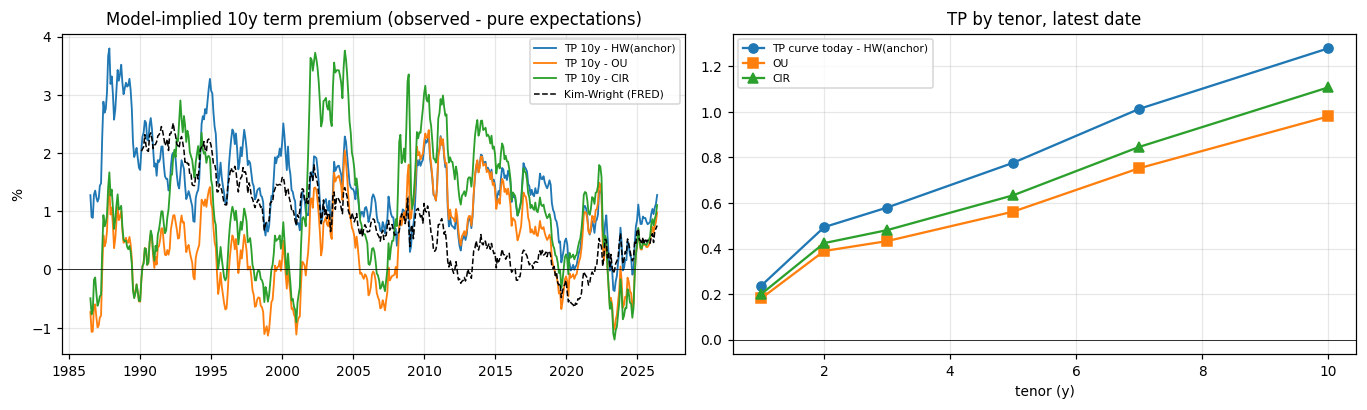

HONESTY CHECK - is the model TP just the slope in disguise?  (and does it track Kim-Wright?)

            corr(TP10, slope)  corr(TP10, Kim-Wright)
HW(anchor)             0.3460                  0.6996
OU                     0.7690                  0.0277
CIR                    0.8874                  0.1818

  corr with slope ~0.9+ would mean little new information beyond the classic steepness signal.


In [5]:
# ===== SECTION B: pure-expectations curves -> per-tenor MODEL TERM PREMIUM =====
def vas_B(tau,k): k=max(k,1e-4); return (1-np.exp(-k*tau))/k
def vas_yield(tau,rr,k,th,s):
    k=max(k,1e-4); B=vas_B(tau,k)
    lnA=(th - s*s/(2*k*k))*(B-tau) - s*s*B*B/(4*k)
    return (-lnA + B*rr)/tau
def cir_yield(tau,rr,k,th,s):
    k=max(k,1e-4); s=max(s,1e-4); g=np.sqrt(k*k+2*s*s)
    eg=np.exp(g*tau); den=(g+k)*(eg-1)+2*g
    B=2*(eg-1)/den; lnA=(2*k*th/(s*s))*np.log(2*g*np.exp((k+g)*tau/2)/den)
    return (-lnA + B*rr)/tau
TAUS=np.array(MATS_L,float); nta=len(TAUS)
TPHW=np.full((Tn,nta),np.nan); TPOU=np.full((Tn,nta),np.nan); TPCIR=np.full((Tn,nta),np.nan)
for t in range(MINW,Tn):
    for j,tau in enumerate(TAUS):
        TPOU[t,j]=Y[t,j]-vas_yield(tau,r[t],kOU_t[t],thOU_t[t],sOU_t[t])
        TPHW[t,j]=Y[t,j]-vas_yield(tau,r[t],kHW_t[t],anchor_sr[t],sHW_t[t])
        TPCIR[t,j]=Y[t,j]-cir_yield(tau,r[t],kC_t[t],thC_t[t],sC_t[t])
slope=Y[:,-1]-Y[:,0]
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,2,figsize=(12.5,3.8))
for nm,TP in [("HW(anchor)",TPHW),("OU",TPOU),("CIR",TPCIR)]:
    ax[0].plot(dates,TP[:,-1]*100,lw=1.2,label=f"TP 10y - {nm}")
if tp_series is not None:
    ax[0].plot(dates,np.asarray(tp_series,float)*100,"k--",lw=1.0,label="Kim-Wright (FRED)")
ax[0].axhline(0,color="k",lw=.5); ax[0].set_ylabel("%"); ax[0].legend(fontsize=7)
ax[0].set_title("Model-implied 10y term premium (observed - pure expectations)")
ax[1].plot(TAUS,TPHW[-1]*100,marker="o",label="TP curve today - HW(anchor)")
ax[1].plot(TAUS,TPOU[-1]*100,marker="s",label="OU"); ax[1].plot(TAUS,TPCIR[-1]*100,marker="^",label="CIR")
ax[1].axhline(0,color="k",lw=.5); ax[1].set_xlabel("tenor (y)"); ax[1].legend(fontsize=7); ax[1].set_title("TP by tenor, latest date")
plt.tight_layout(); plt.show()
fin=np.isfinite(TPHW[:,-1])
rows={}
for nm,TP in [("HW(anchor)",TPHW),("OU",TPOU),("CIR",TPCIR)]:
    d={"corr(TP10, slope)":float(np.corrcoef(TP[fin,-1],slope[fin])[0,1])}
    if tp_series is not None:
        kw=np.asarray(tp_series,float); m=fin&np.isfinite(kw)
        d["corr(TP10, Kim-Wright)"]=float(np.corrcoef(TP[m,-1],kw[m])[0,1])
    rows[nm]=d
print("HONESTY CHECK - is the model TP just the slope in disguise?  (and does it track Kim-Wright?)\n")
print(pd.DataFrame(rows).T.to_string())
print("\n  corr with slope ~0.9+ would mean little new information beyond the classic steepness signal.")


## Section C — the predictive battery

Same discipline as the previous notebooks: per-tenor excess returns
$rx^{(n)}_{t\to t+12}=n\,y_t(n)-(n\!-\!1)\,y_{t+12}(n\!-\!1)-y_t(1)$ (off-grid maturities
interpolated), Newey–West t-stats (overlapping 12m windows), and the **out-of-sample $R^2$**
against the expanding-mean benchmark. The horse-race answers the only question that matters:
does the anchor-model TP carry information **beyond the slope and Fama–Bliss** — and does
anything survive OOS?

In [6]:
# ===== SECTION C: does the MODEL term premium predict excess returns? (five-test battery) =====
H=12
def y_at(m):  # yield at (possibly off-grid) maturity m, per date
    return np.array([np.interp(m,TAUS,Y[t]) for t in range(Tn)])
# per-tenor 12m excess returns  rx(n) = n*y_t(n) - (n-1)*y_{t+12}(n-1) - y_t(1)
TEN=[2,3,5,7,10]; RX={}
y1=Y[:,0]
for n in TEN:
    ynm1=y_at(n-1); rx=np.full(Tn,np.nan)
    for t in range(Tn-H): rx[t]=n*Y[t,TAUS.tolist().index(n)]-(n-1)*ynm1[t+H]-y1[t]
    RX[n]=rx
rx_bar=np.nanmean(np.column_stack([RX[n] for n in TEN]),axis=1)
# per-tenor monthly returns from the curve (used by the distributional layer too)
Dm=TAUS; Cm=TAUS**2; hh=1/12
dYm=np.vstack([np.zeros((1,nta)),np.diff(Y,axis=0)])
rollm=np.zeros_like(Y)
for t in range(Tn): rollm[t]=Dm*(Y[t]-np.interp(TAUS-hh,TAUS,Y[t]))
RET_pt=Y/12+rollm-Dm[None,:]*dYm+0.5*Cm[None,:]*dYm**2
basket1m=RET_pt[:,1:].mean(1)-r/12          # 2..10y average, excess of cash

# predictors (all built from expanding-window params or observables at t)
tpHW_bar=np.nanmean(TPHW[:,1:],axis=1); tpOU_bar=np.nanmean(TPOU[:,1:],axis=1)
fs=[]
for j in range(1,nta):
    f=(TAUS[j]*Y[:,j]-TAUS[j-1]*Y[:,j-1])/(TAUS[j]-TAUS[j-1]); fs.append(f-y1)
fb_bar=np.column_stack(fs).mean(1)
gap_legacy=Y[:,-1]-(anchor_sr+0.005)
def ols_nw(yv,Xc,L):
    X=np.column_stack([np.ones(len(yv))]+[c for c in Xc]); b=np.linalg.lstsq(X,yv,rcond=None)[0]
    e=yv-X@b; XtX=np.linalg.inv(X.T@X); Xe=X*e[:,None]; S=Xe.T@Xe
    for l in range(1,L+1):
        w=1-l/(L+1); G=Xe[l:].T@Xe[:-l]; S=S+w*(G+G.T)
    V=XtX@S@XtX; return b,np.sqrt(np.diag(V)),1-(e@e)/(((yv-yv.mean())**2).sum())
def oos_r2(P,yv,H,minobs=MINW):
    P=P.reshape(-1,1) if P.ndim==1 else P; T2=len(yv); num=den=0.0; nf=0
    for t in range(minobs+H,T2):
        if not np.isfinite(yv[t]) or not np.isfinite(P[t]).all(): continue
        s_=np.arange(0,t-H+1); m=np.isfinite(yv[s_])&np.isfinite(P[s_]).all(1)
        if m.sum()<minobs: continue
        Xtr=np.column_stack([np.ones(m.sum()),P[s_][m]]); btr=np.linalg.lstsq(Xtr,yv[s_][m],rcond=None)[0]
        num+=(yv[t]-(btr[0]+P[t]@btr[1:]))**2; den+=(yv[t]-yv[s_][m].mean())**2; nf+=1
    return (1-num/den if den>0 else np.nan),nf
def is_r2(P,yv):
    f=(np.isfinite(yv)&np.isfinite(P).all(1)) if P.ndim>1 else (np.isfinite(yv)&np.isfinite(P))
    Pm=P[f].reshape(-1,1) if P.ndim==1 else P[f]; X=np.column_stack([np.ones(f.sum()),Pm])
    b=np.linalg.lstsq(X,yv[f],rcond=None)[0]; e=yv[f]-X@b; return 1-(e@e)/(((yv[f]-yv[f].mean())**2).sum())

print("PER-TENOR in-sample:  rx(n) ~ TP_HW(n)   [Newey-West, lag 12]")
for j,n in enumerate(TEN):
    p=TPHW[:,j+1]; yv=RX[n]; f=np.isfinite(p)&np.isfinite(yv)
    pz=(p[f]-p[f].mean())/p[f].std(); b,se,r2=ols_nw(yv[f],[pz],H)
    print(f"  n={n:>2}y: beta/SD {b[1]*100:+5.2f}%/12m | NW t {b[1]/se[1]:5.2f} | R2 {r2:5.3f}")
f=np.isfinite(tpHW_bar)&np.isfinite(rx_bar)
pz=(tpHW_bar[f]-tpHW_bar[f].mean())/tpHW_bar[f].std(); b,se,r2=ols_nw(rx_bar[f],[pz],H)
print(f"\nBASKET in-sample: beta/SD {b[1]*100:+.2f}%/12m | NW t {b[1]/se[1]:.2f} | R2 {r2:.3f}\n")
preds={"TP_HW (anchor model)":tpHW_bar.reshape(-1,1),"TP_OU (const theta)":tpOU_bar.reshape(-1,1),
       "Slope (y10-y1)":slope.reshape(-1,1),"Fama-Bliss fwd spread":fb_bar.reshape(-1,1),
       "Legacy anchor gap (10y)":gap_legacy.reshape(-1,1),
       "Slope + TP_HW":np.column_stack([slope,tpHW_bar])}
rows={}
for nm,P in preds.items():
    o,nf=oos_r2(P,rx_bar,H); rows[nm]={"InSample_R2":is_r2(P,rx_bar),"OOS_R2":o,"n_oos":nf}
print("HORSE-RACE (target: next-12m basket excess return)\n")
print(pd.DataFrame(rows).T[["InSample_R2","OOS_R2","n_oos"]].to_string())
print("\n  Read: does the anchor-model TP beat/add-to the classic slope & Fama-Bliss? Is any OOS_R2 > 0?")


PER-TENOR in-sample:  rx(n) ~ TP_HW(n)   [Newey-West, lag 12]
  n= 2y: beta/SD +0.25%/12m | NW t  2.06 | R2 0.035
  n= 3y: beta/SD +0.48%/12m | NW t  2.10 | R2 0.037
  n= 5y: beta/SD +1.24%/12m | NW t  2.80 | R2 0.076
  n= 7y: beta/SD +2.08%/12m | NW t  3.35 | R2 0.117
  n=10y: beta/SD +3.48%/12m | NW t  3.87 | R2 0.172

BASKET in-sample: beta/SD +1.32%/12m | NW t 3.04 | R2 0.087



/tmp/ipykernel_5109/3901347111.py:12: RuntimeWarning: Mean of empty slice
  rx_bar=np.nanmean(np.column_stack([RX[n] for n in TEN]),axis=1)
/tmp/ipykernel_5109/3901347111.py:22: RuntimeWarning: Mean of empty slice
  tpHW_bar=np.nanmean(TPHW[:,1:],axis=1); tpOU_bar=np.nanmean(TPOU[:,1:],axis=1)


HORSE-RACE (target: next-12m basket excess return)

                         InSample_R2  OOS_R2    n_oos
TP_HW (anchor model)          0.0869  0.0116 336.0000
TP_OU (const theta)           0.0819 -0.0797 336.0000
Slope (y10-y1)                0.0747 -0.0093 455.0000
Fama-Bliss fwd spread         0.0878 -0.0090 455.0000
Legacy anchor gap (10y)       0.1282 -0.4799 455.0000
Slope + TP_HW                 0.1170 -0.0662 336.0000

  Read: does the anchor-model TP beat/add-to the classic slope & Fama-Bliss? Is any OOS_R2 > 0?


## Section D — using the *distributions*, not just the means

This is the part classical signals cannot do, and where your closed-form idea earns its
keep. **PIT calibration**: if the model's 12m-ahead distribution of the short rate is right,
the realised rate should fall uniformly across its predicted quantiles (the Kupiec of
distributions; note 12m observations overlap, so read shapes, not p-value stars).
**Variance-forecast race**: CIR says vol $\propto\sqrt{r}$ — does that level-dependent,
model-based variance forecast realised variance better than trailing realised? (The honest
claim: second moments are more predictable than first.) **Convexity**: when model variance is
high, wings should beat belly — checked by quintile. **Sizing**: with $E[rx]$ *and* $SD[rx]$
in closed form, position $\propto E/SD$ is an ex-ante t-stat — compared against static, sign,
and mean-only sizing, plus a **tail throttle** that de-risks when $P(rx_{12m}<-5\%)$ is high.
**ZLB flag**: OU's Gaussian lower tail goes negative, CIR's non-central-$\chi^2$ cannot —
their 1% quantiles diverging is a clean, model-based zero-bound regime indicator.

PIT CALIBRATION of the 12m-ahead SHORT-RATE distribution (expanding params, u should be ~Uniform)
  OU  : KS D 0.209, p~0.000 | CIR : KS D 0.093, p~0.001
  (12m observations OVERLAP -> p-values overstate significance; read shapes, not stars)


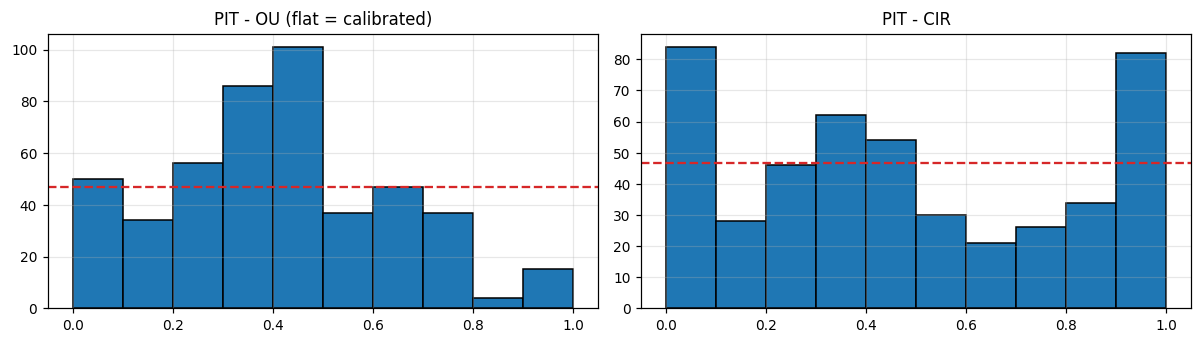

VARIANCE FORECAST of the short rate (the claim: 2nd moments are more predictable than 1st)

                           corr(pred, future RV)  OOS_R2
Trailing realized var                     0.5213  0.6849
OU model var (const)                      0.1499 -0.0873
CIR model var (level-dep)                 0.2406  0.0132

Subsequent 12m BELLY-minus-WINGS return by CIR model-variance quintile (%): [np.float64(-0.11), np.float64(0.32), np.float64(0.23), np.float64(0.02), np.float64(-0.02)]
  (high model variance -> convexity/wings should win -> belly-minus-wings NEGATIVE in Q5)


In [7]:
# ===== SECTION D1: the distributions themselves - PIT calibration, variance forecast, convexity =====
import matplotlib.pyplot as plt
uOU=[]; uCIR=[]
for t in range(MINW,Tn-12):
    k,th,s=kOU_t[t],thOU_t[t],sOU_t[t]
    m=th+(r[t]-th)*np.exp(-k); v=s*s*(1-np.exp(-2*k))/(2*k)
    from statistics import NormalDist
    uOU.append(NormalDist(m,np.sqrt(max(v,1e-12))).cdf(r[t+12]))
    k,th,s=kC_t[t],thC_t[t],sC_t[t]
    if HAVE_SCIPY:
        from scipy.stats import ncx2
        c=2*k/(s*s*(1-np.exp(-k))); df=4*k*th/(s*s); nc=2*c*max(r[t],1e-6)*np.exp(-k)
        uCIR.append(float(ncx2.cdf(2*c*max(r[t+12],1e-6),df,nc)))
    else:
        mm=th+(r[t]-th)*np.exp(-k)
        vv=max(r[t],1e-6)*(s*s/k)*(np.exp(-k)-np.exp(-2*k))+th*(s*s/(2*k))*(1-np.exp(-k))**2
        uCIR.append(NormalDist(mm,np.sqrt(max(vv,1e-12))).cdf(r[t+12]))
uOU=np.array(uOU); uCIR=np.array(uCIR)
def ks_u(u):
    u=np.sort(u); nn=len(u); i=np.arange(1,nn+1)
    D=max(np.max(i/nn-u),np.max(u-(i-1)/nn))
    p=2*sum((-1)**(k-1)*np.exp(-2*k*k*nn*D*D) for k in range(1,101))
    return D,min(max(p,0),1)
DO,pO=ks_u(uOU); DC,pC=ks_u(uCIR)
print("PIT CALIBRATION of the 12m-ahead SHORT-RATE distribution (expanding params, u should be ~Uniform)")
print(f"  OU  : KS D {DO:.3f}, p~{pO:.3f} | CIR : KS D {DC:.3f}, p~{pC:.3f}")
print("  (12m observations OVERLAP -> p-values overstate significance; read shapes, not stars)")
fig,ax=plt.subplots(1,2,figsize=(11,3.2))
ax[0].hist(uOU,bins=10,range=(0,1),edgecolor="k"); ax[0].axhline(len(uOU)/10,color="C3",ls="--"); ax[0].set_title("PIT - OU (flat = calibrated)")
ax[1].hist(uCIR,bins=10,range=(0,1),edgecolor="k"); ax[1].axhline(len(uCIR)/10,color="C3",ls="--"); ax[1].set_title("PIT - CIR")
plt.tight_layout(); plt.show()

# variance forecast: does CIR's level-dependent vol beat trailing realized?
dr=np.diff(r,prepend=r[0])
RV=np.full(Tn,np.nan)
for t in range(Tn-12): RV[t]=np.var(dr[t+1:t+13])*12
trail=np.full(Tn,np.nan)
for t in range(12,Tn): trail[t]=np.var(dr[t-11:t+1])*12
vOU=sOU_t**2; vCIR=sC_t**2*np.maximum(r,1e-4)
rows={}
for nm,P in [("Trailing realized var",trail),("OU model var (const)",vOU),("CIR model var (level-dep)",vCIR)]:
    o,nf=oos_r2(P.reshape(-1,1),RV,12); f=np.isfinite(P)&np.isfinite(RV)
    rows[nm]={"corr(pred, future RV)":float(np.corrcoef(P[f],RV[f])[0,1]),"OOS_R2":o}
print("VARIANCE FORECAST of the short rate (the claim: 2nd moments are more predictable than 1st)\n")
print(pd.DataFrame(rows).T.to_string())

# convexity: subsequent 12m belly-vs-wings return by model-variance quintile
fly=RET_pt[:,TAUS.tolist().index(5)]-0.5*(RET_pt[:,TAUS.tolist().index(2)]+RET_pt[:,TAUS.tolist().index(10)])
fly12=np.full(Tn,np.nan)
for t in range(Tn-12): fly12[t]=np.nansum(fly[t+1:t+13])
f=np.isfinite(vCIR)&np.isfinite(fly12)
q=pd.qcut(pd.Series(vCIR[f]),5,labels=False,duplicates="drop")
mq=[np.nanmean(fly12[f][q==k])*100 for k in range(int(q.max())+1)]
print("\nSubsequent 12m BELLY-minus-WINGS return by CIR model-variance quintile (%):",[round(v,2) for v in mq])
print("  (high model variance -> convexity/wings should win -> belly-minus-wings NEGATIVE in Q5)")


/tmp/ipykernel_5109/11330595.py:5: RuntimeWarning: Mean of empty slice
  tpg=np.nanmean(TPHW[:,1:],axis=1)


DISTRIBUTION-AWARE DURATION SIZING on the 2-10y basket (signals lagged 1m, post burn-in)

                             Sharpe  AnnVol   MaxDD  Turnover
Static long duration         0.5754  0.0422 -0.1971    0.0000
Sign of E[rx] (model)        0.7133  0.0419 -0.1112    0.5150
Linear in E[rx]              0.7488  0.0271 -0.0803    0.7789
z-sized  E/SD (closed form)  0.6338  0.0230 -0.0606    0.5050
z-sized + tail throttle      0.6257  0.0229 -0.0606    0.4979


/usr/local/lib/python3.12/dist-packages/scipy/_lib/array_api_extra/_lib/_funcs.py:160: RuntimeWarning: Error in function boost::math::tools::bracket_and_solve_root<d>: Unable to bracket root, last nearest value was %1%
  temp1 = f1(*(arr[cond] for arr in args))
/usr/local/lib/python3.12/dist-packages/scipy/_lib/array_api_extra/_lib/_funcs.py:160: RuntimeWarning: Error in function quantile(non_central_chi_squared_distribution<d>, %1%): Unable to locate solution in a reasonable time: either there is no answer to quantile or the answer is infinite.  Current best guess is %1%
  temp1 = f1(*(arr[cond] for arr in args))


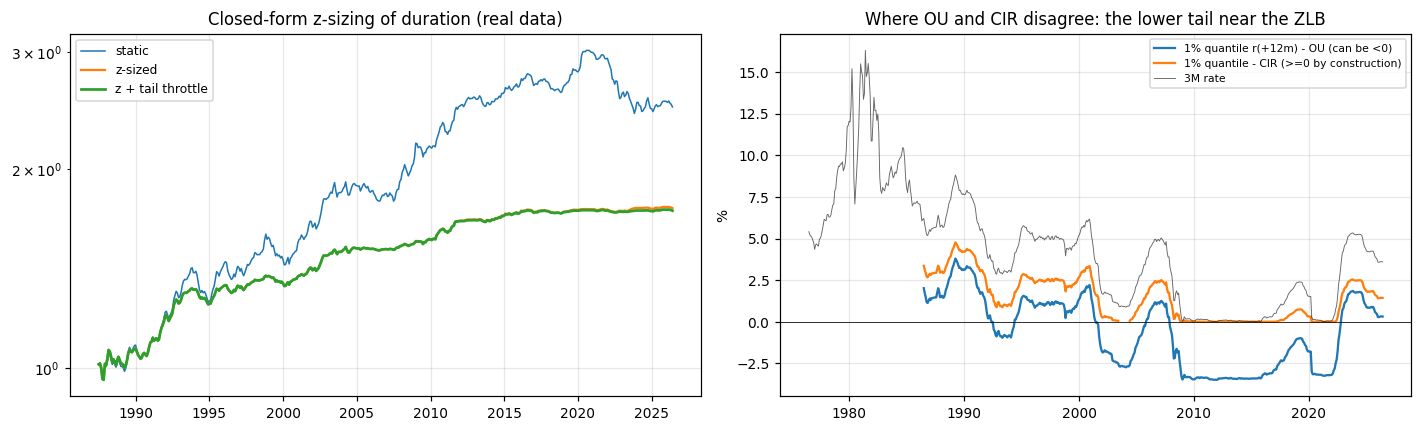


OU-vs-CIR lower-tail disagreement: mean 2.00% | max 3.48% at 2011-09-30
  Disagreement spikes when rates approach zero: a model-based ZLB-regime flag.


In [8]:
# ===== SECTION D2: distribution-aware duration sizing + tail throttle + ZLB disagreement =====
import matplotlib.pyplot as plt
from statistics import NormalDist
Erx=np.full(Tn,np.nan); SDrx=np.full(Tn,np.nan)
tpg=np.nanmean(TPHW[:,1:],axis=1)
for t in range(MINW,Tn):
    k,s=kHW_t[t],sHW_t[t]; th=anchor_sr[t]
    Er12=th+(r[t]-th)*np.exp(-k)
    sd12=s*np.sqrt((1-np.exp(-2*k))/(2*max(k,1e-4)))
    Es=[]; Bs=[]
    for n in [2,3,5,7,10]:
        m=n-1
        yhat=vas_yield(m,Er12,k,th,s)+float(np.interp(m,TAUS,TPHW[t]))
        Es.append(n*float(np.interp(n,TAUS,Y[t]))-(n-1)*yhat-Y[t,0])
        Bs.append(vas_B(m,k))
    Erx[t]=np.mean(Es); SDrx[t]=np.mean(Bs)*sd12
z=Erx/np.maximum(SDrx,1e-6)
p_tail=np.array([NormalDist(Erx[t],max(SDrx[t],1e-6)).cdf(-0.05) if np.isfinite(Erx[t]) else np.nan for t in range(Tn)])
mult=np.where(p_tail<0.05,1.0,np.maximum(0.25,1-(p_tail-0.05)*7.5))
w_static=np.ones(Tn); w_sign=np.sign(Erx); w_lin=np.clip(Erx/0.02,-2,2); w_z=np.clip(z,-2,2); w_zt=w_z*mult
def lag(w): w2=np.roll(w,1); w2[0]=0; return np.where(np.isfinite(w2),w2,0)
def stats_w(w,nm):
    ret=lag(w)*basket1m; rr=ret[MINW+12:]; rr=rr[np.isfinite(rr)]
    sh=rr.mean()/rr.std()*np.sqrt(12) if rr.std()>0 else np.nan
    cum=np.cumprod(1+rr); mdd=(cum/np.maximum.accumulate(cum)-1).min()
    to=np.nanmean(np.abs(np.diff(w[MINW+12:])))*12
    return {"Sharpe":sh,"AnnVol":rr.std()*np.sqrt(12),"MaxDD":mdd,"Turnover":to}
tbl=pd.DataFrame({nm:stats_w(w,nm) for nm,w in [("Static long duration",w_static),("Sign of E[rx] (model)",w_sign),
     ("Linear in E[rx]",w_lin),("z-sized  E/SD (closed form)",w_z),("z-sized + tail throttle",w_zt)]}).T
print("DISTRIBUTION-AWARE DURATION SIZING on the 2-10y basket (signals lagged 1m, post burn-in)\n")
print(tbl.to_string())
fig,ax=plt.subplots(1,2,figsize=(13,4))
for w,nm,lw in [(w_static,"static",1.0),(w_z,"z-sized",1.5),(w_zt,"z + tail throttle",1.8)]:
    ret=pd.Series(lag(w)*basket1m,index=dates).iloc[MINW+12:].fillna(0)
    ax[0].plot(ret.index,(1+ret).cumprod().values,lw=lw,label=nm)
ax[0].set_yscale("log"); ax[0].legend(fontsize=8); ax[0].set_title("Closed-form z-sizing of duration (real data)")
# ZLB disagreement: 1% quantile of r_{t+12}, OU vs CIR
q1o=np.full(Tn,np.nan); q1c=np.full(Tn,np.nan); z01=NormalDist().inv_cdf(0.01)
for t in range(MINW,Tn):
    k,th,s=kOU_t[t],thOU_t[t],sOU_t[t]
    m=th+(r[t]-th)*np.exp(-k); v=s*s*(1-np.exp(-2*k))/(2*k); q1o[t]=m+z01*np.sqrt(max(v,1e-12))
    k,th,s=kC_t[t],thC_t[t],sC_t[t]
    if HAVE_SCIPY:
        from scipy.stats import ncx2
        c=2*k/(s*s*(1-np.exp(-k))); df=4*k*th/(s*s); nc=2*c*max(r[t],1e-6)*np.exp(-k)
        q1c[t]=float(ncx2.ppf(0.01,df,nc))/(2*c)
    else:
        mm=th+(r[t]-th)*np.exp(-k); vv=max(r[t],1e-6)*(s*s/k)*(np.exp(-k)-np.exp(-2*k))+th*(s*s/(2*k))*(1-np.exp(-k))**2
        q1c[t]=max(mm+z01*np.sqrt(max(vv,1e-12)),0.0)
ax[1].plot(dates,q1o*100,label="1% quantile r(+12m) - OU (can be <0)")
ax[1].plot(dates,q1c*100,label="1% quantile - CIR (>=0 by construction)")
ax[1].plot(dates,r*100,color="k",lw=.6,alpha=.6,label="3M rate")
ax[1].axhline(0,color="k",lw=.5); ax[1].legend(fontsize=7); ax[1].set_ylabel("%")
ax[1].set_title("Where OU and CIR disagree: the lower tail near the ZLB")
plt.tight_layout(); plt.show()
dis=np.abs(q1o-q1c); f=np.isfinite(dis)
print(f"\nOU-vs-CIR lower-tail disagreement: mean {np.nanmean(dis)*100:.2f}% | max {np.nanmax(dis)*100:.2f}% at {dates[np.nanargmax(np.where(f,dis,-1))].date()}")
print("  Disagreement spikes when rates approach zero: a model-based ZLB-regime flag.")


## How to read the result — and the honest verdict template

1. **Section A**: is $\kappa_{HW}$ (reversion *to the anchor*) significant (gap-slope t)?
   That is the thesis as an estimated parameter. Compare half-lives: front-end reversion
   should be far faster than anything the 10y showed.
2. **Section B**: corr(TP, slope) — if ~0.9+, the model TP is mostly the old steepness
   signal; corr with Kim–Wright — does a 3-parameter transparent model track the Fed's
   5-factor benchmark?
3. **Section C**: the per-tenor NW table (expect the long end to carry it, if anything) and
   the **OOS_R2 column** — the verdict on predictability. Fragile-OOS is the *expected*
   outcome; report it straight.
4. **Section D**: PIT shapes (which density is closer to flat — and where it fails: tails?
   post-2008?); whether **CIR variance beats trailing realized** (the distributional claim);
   whether **z-sizing / tail-throttle improve risk-adjusted results** vs mean-only sizing —
   that is the practical payoff of closed-form distributions even if the mean signal is weak.

**Limitations to state up front**: one-factor misfit (part of TP is model error — treat TP
relative to its own history); $\hat\kappa$ small-sample bias; CIR misbehaves at the ZLB
(vol→0 — empirically false, and visible in the PIT); HW holds the anchor flat over the
horizon; transaction costs not modelled in the sizing table; and the usual single-sample,
post-1976 caveat. The deliverable is not "a better forecaster" — it is the macro-anchor made
**rigorous**: a process whose reversion is estimated where it exists, whose term premium is
an output, and whose *distributions* are put to work and to the test.

## Significance of the OOS gain — Clark–West test

The horse-race gave TP_HW the project's first **positive** out-of-sample $R^2$ (+0.012). A
positive point estimate is not yet evidence: for **nested** forecasts (expanding mean vs
expanding mean + predictor) the right significance test is **Clark–West (2007)** — the
adjusted-MSPE statistic corrects for the noise the larger model adds under the null. One-sided,
Newey–West lag 12 for the overlapping 12-month target. Read the verdict column honestly: above
~1.28 (10%) the OOS gain is more than luck; below, the claim stays "survives OOS, indicatively"
— still the only predictor here that does, but without a star.

In [9]:
# ===== Clark-West (2007) test: is the OOS gain of TP_HW statistically significant? =====
# Nested comparison: benchmark = expanding mean of rx; model = expanding OLS [1, predictor].
# Adjusted MSPE difference  f_t = e_b^2 - ( e_m^2 - (f_b - f_m)^2 );  CW t = mean(f)/NW_se(f).
# One-sided test (H1: model beats benchmark); NW lag 12 for the overlapping 12m target.
from statistics import NormalDist
def clark_west(P,yv,H,minobs=MINW,nwlag=12):
    P=P.reshape(-1,1) if P.ndim==1 else P; fts=[]
    for t in range(minobs+H,len(yv)):
        if not np.isfinite(yv[t]) or not np.isfinite(P[t]).all(): continue
        s_=np.arange(0,t-H+1); m=np.isfinite(yv[s_])&np.isfinite(P[s_]).all(1)
        if m.sum()<minobs: continue
        yb=yv[s_][m].mean()
        Xtr=np.column_stack([np.ones(m.sum()),P[s_][m]]); btr=np.linalg.lstsq(Xtr,yv[s_][m],rcond=None)[0]
        ym=btr[0]+P[t]@btr[1:]
        eb=yv[t]-yb; em=yv[t]-ym
        fts.append(eb*eb-(em*em-(yb-ym)**2))
    f=np.array(fts,float); n=len(f)
    if n<24: return np.nan,np.nan,np.nan,n
    u=f-f.mean(); S=np.sum(u*u)/n
    for l in range(1,nwlag+1):
        w=1-l/(nwlag+1); S+=2*w*np.sum(u[l:]*u[:-l])/n
    se=np.sqrt(S/n); tcw=f.mean()/se; p=1-NormalDist().cdf(tcw)
    return f.mean(),tcw,p,n
rows={}
for nm,P in [("TP_HW (anchor model)",tpHW_bar),("TP_OU (const theta)",tpOU_bar),
             ("Slope (y10-y1)",slope),("Fama-Bliss fwd spread",fb_bar),
             ("Legacy anchor gap (10y)",gap_legacy)]:
    fm,tcw,p,n=clark_west(np.asarray(P,float),rx_bar,H)
    v="** significant 5%" if (np.isfinite(tcw) and tcw>1.645) else ("* significant 10%" if (np.isfinite(tcw) and tcw>1.282) else "not significant")
    rows[nm]={"adjMSPE_diff":fm,"CW_t (NW12)":tcw,"p (1-sided)":p,"n_oos":n,"verdict":v}
print("CLARK-WEST TEST vs the expanding-mean benchmark (one-sided; crit 1.282 @10%, 1.645 @5%)\n")
print(pd.DataFrame(rows).T.to_string())
print("\n  Read: only a CW_t above ~1.28-1.65 lets you claim the positive OOS R2 is more than luck.")
print("  Caveats: overlapping target handled via NW(12) but the test remains asymptotic; windows differ")
print("  slightly across predictors (parameter burn-in); this is the project's third formulation of the")
print("  anchor idea, so apply a multiple-testing discount to borderline stars.")


CLARK-WEST TEST vs the expanding-mean benchmark (one-sided; crit 1.282 @10%, 1.645 @5%)

                        adjMSPE_diff CW_t (NW12) p (1-sided) n_oos            verdict
TP_HW (anchor model)          0.0002      1.3145      0.0943   336  * significant 10%
TP_OU (const theta)           0.0003      1.1923      0.1166   336    not significant
Slope (y10-y1)                0.0005      1.6628      0.0482   455  ** significant 5%
Fama-Bliss fwd spread         0.0005      1.7429      0.0407   455  ** significant 5%
Legacy anchor gap (10y)       0.0004      0.7313      0.2323   455    not significant

  Read: only a CW_t above ~1.28-1.65 lets you claim the positive OOS R2 is more than luck.
  Caveats: overlapping target handled via NW(12) but the test remains asymptotic; windows differ
  slightly across predictors (parameter burn-in); this is the project's third formulation of the
  anchor idea, so apply a multiple-testing discount to borderline stars.


## Common-window comparison — closing the last objection

The CW table above compares predictors over **different** evaluation windows: slope and
Fama–Bliss are judged on ~455 months (from the late 1980s), TP_HW only on ~336 (its
expanding parameters need a 10-year burn-in), so TP_HW never gets credit — or blame — for
the more predictable late-80s/90s. This cell re-runs the **out-of-sample R² and Clark–West
for all five predictors on the identical months** (the window where TP_HW produces
forecasts). This is the like-for-like verdict: if TP_HW keeps a positive OOS R² and its
star here while the classics weaken, the edge is not a window artefact.

In [10]:
# ===== Common-window comparison: every predictor judged on the SAME evaluation period =====
# The tables above evaluate slope/FB over ~455 months but TP_HW over ~336 (its expanding
# parameters need a burn-in). Fair comparison: restrict ALL predictors to the window where
# TP_HW itself produces forecasts.
t0=None
for t in range(MINW+H,Tn):
    if np.isfinite(tpHW_bar[t]) and np.isfinite(rx_bar[t]):
        s_=np.arange(0,t-H+1); m=np.isfinite(tpHW_bar[s_])&np.isfinite(rx_bar[s_])
        if m.sum()>=MINW: t0=t; break
print(f"Common evaluation window: {dates[t0].date()} -> {dates[Tn-1].date()}  (first TP_HW forecast onward)\n")
def oos_r2_w(P,yv,H,start,minobs=MINW):
    P=P.reshape(-1,1) if P.ndim==1 else P; num=den=0.0; nf=0
    for t in range(start,len(yv)):
        if not np.isfinite(yv[t]) or not np.isfinite(P[t]).all(): continue
        s_=np.arange(0,t-H+1); m=np.isfinite(yv[s_])&np.isfinite(P[s_]).all(1)
        if m.sum()<minobs: continue
        Xtr=np.column_stack([np.ones(m.sum()),P[s_][m]]); btr=np.linalg.lstsq(Xtr,yv[s_][m],rcond=None)[0]
        num+=(yv[t]-(btr[0]+P[t]@btr[1:]))**2; den+=(yv[t]-yv[s_][m].mean())**2; nf+=1
    return (1-num/den if den>0 else np.nan),nf
def cw_w(P,yv,H,start,minobs=MINW,nwlag=12):
    from statistics import NormalDist
    P=P.reshape(-1,1) if P.ndim==1 else P; fts=[]
    for t in range(start,len(yv)):
        if not np.isfinite(yv[t]) or not np.isfinite(P[t]).all(): continue
        s_=np.arange(0,t-H+1); m=np.isfinite(yv[s_])&np.isfinite(P[s_]).all(1)
        if m.sum()<minobs: continue
        yb=yv[s_][m].mean()
        Xtr=np.column_stack([np.ones(m.sum()),P[s_][m]]); btr=np.linalg.lstsq(Xtr,yv[s_][m],rcond=None)[0]
        ym=btr[0]+P[t]@btr[1:]; eb=yv[t]-yb; em=yv[t]-ym
        fts.append(eb*eb-(em*em-(yb-ym)**2))
    f=np.array(fts,float); n=len(f)
    if n<24: return np.nan,np.nan,n
    u=f-f.mean(); S=np.sum(u*u)/n
    for l in range(1,nwlag+1):
        w=1-l/(nwlag+1); S+=2*w*np.sum(u[l:]*u[:-l])/n
    tcw=f.mean()/np.sqrt(S/n); return tcw,1-NormalDist().cdf(tcw),n
rows={}
for nm,P in [("TP_HW (anchor model)",tpHW_bar),("TP_OU (const theta)",tpOU_bar),
             ("Slope (y10-y1)",slope),("Fama-Bliss fwd spread",fb_bar),
             ("Legacy anchor gap (10y)",gap_legacy)]:
    P=np.asarray(P,float)
    o,nf=oos_r2_w(P,rx_bar,H,t0); tcw,p,n=cw_w(P,rx_bar,H,t0)
    v="** 5%" if (np.isfinite(tcw) and tcw>1.645) else ("* 10%" if (np.isfinite(tcw) and tcw>1.282) else "-")
    rows[nm]={"OOS_R2 (common)":o,"CW_t (NW12)":tcw,"p (1-sided)":p,"n_oos":n,"sig":v}
print("COMMON-WINDOW HORSE-RACE + CLARK-WEST  (identical evaluation months for every predictor)\n")
print(pd.DataFrame(rows).T.to_string())
print("\n  Read: with the late-80s/90s removed for everyone, this is the like-for-like verdict.")
print("  If TP_HW keeps a positive OOS_R2 and its star while slope/FB weaken, the anchor model's edge")
print("  is not a window artefact; if slope/FB stay ahead, the earlier gap was partly the sample.")


Common evaluation window: 1997-05-31 -> 2026-05-31  (first TP_HW forecast onward)

COMMON-WINDOW HORSE-RACE + CLARK-WEST  (identical evaluation months for every predictor)

                        OOS_R2 (common) CW_t (NW12) p (1-sided) n_oos    sig
TP_HW (anchor model)             0.0116      1.3145      0.0943   336  * 10%
TP_OU (const theta)             -0.0797      1.1923      0.1166   336      -
Slope (y10-y1)                  -0.0100      1.5971      0.0551   336  * 10%
Fama-Bliss fwd spread           -0.0154      1.6159      0.0531   336  * 10%
Legacy anchor gap (10y)         -0.4675      0.5115      0.3045   336      -

  Read: with the late-80s/90s removed for everyone, this is the like-for-like verdict.
  If TP_HW keeps a positive OOS_R2 and its star while slope/FB weaken, the anchor model's edge
  is not a window artefact; if slope/FB stay ahead, the earlier gap was partly the sample.


## Robustness — publication-lag CPI (real-time proxy)

The baseline $\pi_e$ uses CPI as if observable in the same month; in real time it arrives
with ~1 month lag and gets revised. This cell shifts the CPI index by one month, rebuilds
the anchor and the expanding HW parameters, and reruns the core battery (NW t, OOS $R^2$,
Clark–West) side by side with the baseline. Because the trend is a 36-month-half-life EWMA,
a 1-month lag *should* barely matter — this verifies it. Full treatment (revisions) needs
ALFRED vintages; that upgrade is noted, not claimed.

In [11]:
# ===== Robustness: publication-lag CPI (real-time proxy) =====
# The baseline pi_e uses CPI as if known in the same month; in real time CPI arrives with
# ~1 month lag (and gets revised). Cheap but honest proxy: shift the CPI index one month,
# rebuild the anchor and the expanding HW parameters, and rerun the core tests.
cpi_lag=pd.Series(cpi_idx,index=dates).shift(1)
pi_lag=cpi_lag.pct_change(12).ewm(halflife=PI_HL).mean().bfill()
if hlw is not None:
    rst_l=pd.Series(hlw,index=dates).reindex(dates).interpolate().ffill().bfill()
else:
    rst_l=(pd.Series(short,index=dates)-pi_lag).ewm(halflife=RSTAR_HL).mean().bfill()
anchor_lag=(rst_l+pi_lag).to_numpy()
kL_t=np.full(Tn,np.nan); sL_t=np.full(Tn,np.nan)
for t in range(MINW,Tn):
    a,c_,_=fit_hw(r[:t+1],anchor_lag[:t+1]); kL_t[t],sL_t[t]=a,c_
TPL=np.full((Tn,nta),np.nan)
for t in range(MINW,Tn):
    for j,tau in enumerate(TAUS):
        TPL[t,j]=Y[t,j]-vas_yield(tau,r[t],kL_t[t],anchor_lag[t],sL_t[t])
tpL_bar=np.nanmean(TPL[:,1:],axis=1)
def _row(P):
    P=np.asarray(P,float); f=np.isfinite(P)&np.isfinite(rx_bar)
    z=(P-np.nanmean(P[f]))/np.nanstd(P[f])
    b,se,r2=ols_nw(rx_bar[f],[z[f]],H)
    o,_=oos_r2(P.reshape(-1,1),rx_bar,H)
    fm,tcw,p,ncw=clark_west(P,rx_bar,H)
    return {"NW_t":b[1]/se[1],"beta_perSD":b[1],"IS_R2":r2,"OOS_R2":o,"CW_t":tcw,"n":ncw}
tab=pd.DataFrame({"Baseline (same-month CPI)":_row(tpHW_bar),
                  "Publication-lag CPI (t-1)":_row(tpL_bar)}).T
print("ROBUSTNESS - real-time proxy for the inflation input\n")
print(tab.to_string())
d=tab.loc["Publication-lag CPI (t-1)"]; b=tab.loc["Baseline (same-month CPI)"]
verdict="HOLDS" if (d["OOS_R2"]>0 and d["CW_t"]>1.282) else ("WEAKENS but positive" if d["OOS_R2"]>0 else "DOES NOT SURVIVE")
print(f"\nVerdict: the result {verdict} under the 1-month CPI lag (OOS {d['OOS_R2']:+.4f} vs {b['OOS_R2']:+.4f}; CW {d['CW_t']:.2f} vs {b['CW_t']:.2f}).")
print("Full real-time treatment needs ALFRED vintages (revisions, not just lag); the trend EWMA (hl=36m)")
print("makes the signal slow by construction, which is why a 1-month lag should matter little - this cell verifies it.")


/tmp/ipykernel_5109/2426730464.py:19: RuntimeWarning: Mean of empty slice
  tpL_bar=np.nanmean(TPL[:,1:],axis=1)


ROBUSTNESS - real-time proxy for the inflation input

                            NW_t  beta_perSD  IS_R2  OOS_R2   CW_t        n
Baseline (same-month CPI) 3.0448      0.0132 0.0869  0.0116 1.3145 336.0000
Publication-lag CPI (t-1) 3.0741      0.0132 0.0876  0.0093 1.3224 336.0000

Verdict: the result HOLDS under the 1-month CPI lag (OOS +0.0093 vs +0.0116; CW 1.32 vs 1.31).
Full real-time treatment needs ALFRED vintages (revisions, not just lag); the trend EWMA (hl=36m)
makes the signal slow by construction, which is why a 1-month lag should matter little - this cell verifies it.



## Section E — US reconciliation: why does the G10-panel USA look stronger?

The G10 panel uses a deliberately simpler 10-year-only specification: one 10Y yield, one 3M funding rate, CPI-trend anchor, a 10Y affine expectations yield, and a duration-approximated 12m 10Y excess return.  
The US affine notebook uses a richer curve object: several tenors, off-grid Fama-Bliss-style excess returns, and a basket target. These are **not the same experiment**.

This diagnostic reruns the panel-style specification on the same US data already loaded in this notebook, then compares:

1. the original affine **basket** test;
2. the affine **10Y exact excess-return** test;
3. the panel-style **10Y duration-approximation** test;
4. cross-target variants that isolate whether the gap comes from the target, the signal, or the sample.

The purpose is not to optimise anything. It is a reconciliation audit.


In [12]:

# ===== SECTION E: US reconciliation between Affine_V4 and Panel_G10 specifications =====
# Goal: explain why the panel-USA OOS R2 can be much larger than the original US affine basket test.
# This cell uses the SAME US data already loaded in this notebook.

print("US RECONCILIATION: affine-basket vs 10Y-only panel-style specification\n")

# --- Panel-style 10Y-only model, rebuilt on this notebook's US data -----------------
y10 = np.asarray(Y[:, -1], float)
r3m = np.asarray(r, float)

# Same simple CPI/r* proxy used in the panel notebook.
pi_panel = pd.Series(cpi_idx, index=dates).pct_change(12).ewm(halflife=36).mean().bfill().to_numpy()
rstar_panel = (pd.Series(r3m, index=dates) - pd.Series(pi_panel, index=dates)).ewm(halflife=120).mean().bfill().to_numpy()
anchor_panel = rstar_panel + pi_panel

kP = np.full(Tn, np.nan)
sP = np.full(Tn, np.nan)
for t in range(MINW, Tn):
    g = anchor_panel[:t] - r3m[:t]
    d = r3m[1:t+1] - r3m[:t]
    X = np.column_stack([np.ones(t), g])
    a0, sl = np.linalg.lstsq(X, d, rcond=None)[0]
    eps = d - (a0 + sl * g)
    kP[t] = float(np.clip(sl * 12, 1e-4, 20))
    sP[t] = float(np.std(eps) * np.sqrt(12))

TP_panel10 = np.full(Tn, np.nan)
for t in range(MINW, Tn):
    TP_panel10[t] = y10[t] - vas_yield(10.0, r3m[t], kP[t], anchor_panel[t], sP[t])

# Panel-style 12m excess return: 10Y carry/funding plus duration-repricing approximation.
D10 = (1 - (1 + np.maximum(y10, 1e-4)) ** -10) / np.maximum(y10, 1e-4)
rx_panel10 = np.full(Tn, np.nan)
for t in range(Tn - H):
    rx_panel10[t] = y10[t] - D10[t] * (y10[t + H] - y10[t]) - r3m[t]

# Affine notebook's 10Y TP and exact 10Y excess return target.
TP_affine10 = np.asarray(TPHW[:, -1], float)
rx_exact10 = np.asarray(RX[10], float)

# --- local evaluation helpers ------------------------------------------------------
def _first_start(P, yv, H=H, minobs=MINW):
    P = np.asarray(P, float)
    P2 = P.reshape(-1, 1) if P.ndim == 1 else P
    yv = np.asarray(yv, float)
    for t in range(minobs + H, len(yv)):
        if not np.isfinite(yv[t]) or not np.isfinite(P2[t]).all():
            continue
        s_ = np.arange(0, t - H + 1)
        m = np.isfinite(yv[s_]) & np.isfinite(P2[s_]).all(1)
        if m.sum() >= minobs:
            return t
    return None

def _oos_r2_start(P, yv, start, H=H, minobs=MINW):
    P = np.asarray(P, float)
    P = P.reshape(-1, 1) if P.ndim == 1 else P
    yv = np.asarray(yv, float)
    num = den = 0.0
    nf = 0
    for t in range(start, len(yv)):
        if not np.isfinite(yv[t]) or not np.isfinite(P[t]).all():
            continue
        s_ = np.arange(0, t - H + 1)
        m = np.isfinite(yv[s_]) & np.isfinite(P[s_]).all(1)
        if m.sum() < minobs:
            continue
        Xtr = np.column_stack([np.ones(m.sum()), P[s_][m]])
        btr = np.linalg.lstsq(Xtr, yv[s_][m], rcond=None)[0]
        yhat = btr[0] + P[t] @ btr[1:]
        ybar = yv[s_][m].mean()
        num += (yv[t] - yhat) ** 2
        den += (yv[t] - ybar) ** 2
        nf += 1
    return (1 - num / den if den > 0 else np.nan), nf

def _cw_start(P, yv, start, H=H, minobs=MINW, nwlag=12):
    from statistics import NormalDist
    P = np.asarray(P, float)
    P = P.reshape(-1, 1) if P.ndim == 1 else P
    yv = np.asarray(yv, float)
    fts = []
    for t in range(start, len(yv)):
        if not np.isfinite(yv[t]) or not np.isfinite(P[t]).all():
            continue
        s_ = np.arange(0, t - H + 1)
        m = np.isfinite(yv[s_]) & np.isfinite(P[s_]).all(1)
        if m.sum() < minobs:
            continue
        yb = yv[s_][m].mean()
        Xtr = np.column_stack([np.ones(m.sum()), P[s_][m]])
        btr = np.linalg.lstsq(Xtr, yv[s_][m], rcond=None)[0]
        ym = btr[0] + P[t] @ btr[1:]
        eb = yv[t] - yb
        em = yv[t] - ym
        fts.append(eb * eb - (em * em - (yb - ym) ** 2))
    f = np.asarray(fts, float)
    n = len(f)
    if n < 24:
        return np.nan, np.nan, n
    u = f - f.mean()
    S = np.sum(u * u) / n
    for l in range(1, nwlag + 1):
        w = 1 - l / (nwlag + 1)
        S += 2 * w * np.sum(u[l:] * u[:-l]) / n
    tcw = f.mean() / np.sqrt(S / n) if S > 0 else np.nan
    p = 1 - NormalDist().cdf(tcw) if np.isfinite(tcw) else np.nan
    return tcw, p, n

def _eval_pair(name, P, yv, native=True, forced_start=None):
    P = np.asarray(P, float)
    yv = np.asarray(yv, float)
    f = np.isfinite(P) & np.isfinite(yv)
    if f.sum() >= MINW + 24 and np.nanstd(P[f]) > 0:
        z = (P - np.nanmean(P[f])) / np.nanstd(P[f])
        b, se, isr2 = ols_nw(yv[f], [z[f]], H)
        beta = b[1]
        nw_t = beta / se[1]
    else:
        beta = nw_t = isr2 = np.nan
    if native:
        oos, n_oos = oos_r2(P.reshape(-1, 1), yv, H)
        fm, tcw, p, n_cw = clark_west(P, yv, H)
        start = _first_start(P, yv)
    else:
        start = forced_start
        oos, n_oos = _oos_r2_start(P, yv, start)
        tcw, p, n_cw = _cw_start(P, yv, start)
    return {
        "beta_perSD": beta,
        "NW_t": nw_t,
        "IS_R2": isr2,
        "OOS_R2": oos,
        "CW_t": tcw,
        "p_1sided": p,
        "n_oos": n_oos,
        "eval_start": dates[start].date() if start is not None else None,
        "target_mean_ann": np.nanmean(yv[f]) if f.sum() else np.nan,
        "target_vol_ann": np.nanstd(yv[f]) if f.sum() else np.nan,
    }

pairs = {
    "A1 original affine: TP_HW basket -> basket exact rx": (tpHW_bar, rx_bar),
    "A2 affine 10Y only: TP_HW10 -> exact 10Y rx": (TP_affine10, rx_exact10),
    "B1 panel-style on same data: TP_panel10 -> duration-approx 10Y rx": (TP_panel10, rx_panel10),
    "B2 target effect: TP_HW10 -> duration-approx 10Y rx": (TP_affine10, rx_panel10),
    "B3 signal effect: TP_panel10 -> exact 10Y rx": (TP_panel10, rx_exact10),
}

native_tab = pd.DataFrame({k: _eval_pair(k, *v, native=True) for k, v in pairs.items()}).T
print("NATIVE EVALUATION WINDOWS\n")
print(native_tab[["OOS_R2", "CW_t", "p_1sided", "NW_t", "IS_R2", "n_oos", "eval_start"]].to_string())

starts = [_first_start(P, yv) for P, yv in pairs.values()]
common_start = max(s for s in starts if s is not None)
common_tab = pd.DataFrame({k: _eval_pair(k, *v, native=False, forced_start=common_start) for k, v in pairs.items()}).T
print("\nCOMMON EVALUATION WINDOW ACROSS ALL RECONCILIATION PAIRS")
print(f"Start: {dates[common_start].date()} -> {dates[-1].date()}\n")
print(common_tab[["OOS_R2", "CW_t", "p_1sided", "NW_t", "IS_R2", "n_oos", "eval_start"]].to_string())

print("\nREADING GUIDE")
print("- If B1 is much stronger than A1/A2, the G10-USA strength mainly comes from the 10Y duration-approx target/specification, not from the richer basket test.")
print("- If B2 is strong too, the target construction is the main driver. If B3 is weak, the signal change is not the driver.")
print("- If B1 is weak here but strong in the G10 notebook, inspect data-source differences: OECD long-rate vs GS/FRED curve, sample dates, and publication/revision conventions.")
print("- This cell is an audit, not a new optimisation layer. It should be reported before using the G10 panel as headline evidence.")


US RECONCILIATION: affine-basket vs 10Y-only panel-style specification

NATIVE EVALUATION WINDOWS

                                                                  OOS_R2   CW_t p_1sided   NW_t  IS_R2 n_oos  eval_start
A1 original affine: TP_HW basket -> basket exact rx               0.0116 1.3145   0.0943 3.0448 0.0869   336  1997-05-31
A2 affine 10Y only: TP_HW10 -> exact 10Y rx                       0.0851 2.2463   0.0123 3.8674 0.1722   336  1997-05-31
B1 panel-style on same data: TP_panel10 -> duration-approx 10Y rx 0.1395 2.6981   0.0035 4.3147 0.2113   336  1997-05-31
B2 target effect: TP_HW10 -> duration-approx 10Y rx               0.1395 2.6981   0.0035 4.3147 0.2113   336  1997-05-31
B3 signal effect: TP_panel10 -> exact 10Y rx                      0.0851 2.2463   0.0123 3.8674 0.1722   336  1997-05-31

COMMON EVALUATION WINDOW ACROSS ALL RECONCILIATION PAIRS
Start: 1997-05-31 -> 2026-05-31

                                                                  OOS_R2   CW_t p_1s


## Section F — Row-by-row audit: US affine data vs G10-panel USA data

This is the final reconciliation audit. Section E showed that the 10Y target/signal choice explains the weak basket result. This section checks whether the remaining discrepancy between the US affine notebook and the G10-panel notebook is driven by **data source / alignment / target construction**.

It compares, month by month:

1. raw 10Y yield;
2. raw 3M rate;
3. CPI YoY and EWMA inflation trend;
4. proxy \(r^*\), macro anchor \(r^*+\pi_e\);
5. expanding \(\kappa\), \(\sigma\);
6. model-implied TP10;
7. duration-approximated 10Y excess return;
8. OOS and Clark–West performance under identical evaluation windows.

Interpretation: if the panel and affine source series disagree materially, the G10-USA discrepancy is a **data-source/alignment issue**, not a model-theory issue. If the series agree but performance differs, the issue is evaluation-window or target construction.


In [13]:

# ===== SECTION F: row-by-row audit, US affine data vs G10-panel USA data =====
# This cell uses the affine notebook's already-loaded US data, then fetches the USA series
# used by the G10 panel notebook and compares both pipelines row by row.

import numpy as np, pandas as pd, warnings
from pathlib import Path
pd.set_option("display.float_format", lambda v: f"{v:,.6f}")

print("ROW-BY-ROW AUDIT: affine-US source vs G10-panel-USA source\n")

# ---------- Fetch the exact USA panel-source series used in MacroAnchor_Panel_G10 ----------
def _fetch_one(sid):
    d = fred_series([sid])
    if d is None or sid not in d.columns or d[sid].notna().sum() < 60:
        return None
    return d[sid]

# Panel notebook source definitions:
# y10: OECD/FRED long-term govt yield IRLTLT01USM156N
# r3m: OECD/FRED 3M interbank IR3TIB01USM156N
# cpi: OECD CPI USACPIALLMINMEI, fallback CPIAUCSL
panel_y10_raw = _fetch_one("IRLTLT01USM156N")
panel_r3m_raw = _fetch_one("IR3TIB01USM156N")
panel_cpi_raw = _fetch_one("USACPIALLMINMEI")
panel_cpi_id = "USACPIALLMINMEI"
if panel_cpi_raw is None:
    panel_cpi_raw = _fetch_one("CPIAUCSL")
    panel_cpi_id = "CPIAUCSL"

if panel_y10_raw is None or panel_r3m_raw is None or panel_cpi_raw is None:
    raise RuntimeError("Could not fetch one or more USA panel-source series from FRED.")

panel_raw = pd.DataFrame({
    "y10": panel_y10_raw.resample("ME").last() / 100.0,
    "r3m": panel_r3m_raw.resample("ME").last() / 100.0,
    "cpi": panel_cpi_raw.resample("ME").last().interpolate(),
}).dropna()
panel_raw.attrs["source"] = f"G10 panel USA: IRLTLT01USM156N / IR3TIB01USM156N / {panel_cpi_id}"

# Affine notebook source actually loaded in this run:
# y10: last column of Y (GS10 when GSW fallback is active, or GSW 10y when available)
# r3m: TB3MS
# cpi: CPIAUCSL
affine_raw = pd.DataFrame({
    "y10": pd.Series(np.asarray(Y[:, -1], float), index=pd.DatetimeIndex(dates)),
    "r3m": pd.Series(np.asarray(r, float), index=pd.DatetimeIndex(dates)),
    "cpi": pd.Series(np.asarray(cpi_idx, float), index=pd.DatetimeIndex(dates)),
}).dropna()
affine_raw.attrs["source"] = f"Affine US: {CURVE_SRC}; short=TB3MS; CPI=CPIAUCSL"

print("Affine source:", affine_raw.attrs["source"])
print("Panel source: ", panel_raw.attrs["source"])
print(f"Affine months: {affine_raw.index[0].date()} -> {affine_raw.index[-1].date()} | n={len(affine_raw)}")
print(f"Panel months:  {panel_raw.index[0].date()} -> {panel_raw.index[-1].date()} | n={len(panel_raw)}\n")

# ---------- Build the same panel-style model outputs on each source ----------
def _build_panel_style(df, label, minw=120, H=12):
    df = df.copy().sort_index()
    idx = df.index
    n = len(df)
    y10 = df["y10"].astype(float).to_numpy()
    r3m = df["r3m"].astype(float).to_numpy()
    cpi = df["cpi"].astype(float)

    pi = cpi.pct_change(12).ewm(halflife=36).mean().bfill()
    rstar = (pd.Series(r3m, index=idx) - pi).ewm(halflife=120).mean().bfill()
    anchor = rstar + pi

    kt = np.full(n, np.nan)
    st = np.full(n, np.nan)
    for t in range(minw, n):
        g = anchor.iloc[:t].to_numpy() - r3m[:t]
        d = r3m[1:t+1] - r3m[:t]
        X = np.column_stack([np.ones(t), g])
        a0, sl = np.linalg.lstsq(X, d, rcond=None)[0]
        eps = d - (a0 + sl * g)
        kt[t] = float(np.clip(sl * 12, 1e-4, 20))
        st[t] = float(np.std(eps) * np.sqrt(12))

    tp10 = np.full(n, np.nan)
    for t in range(minw, n):
        tp10[t] = y10[t] - vas_yield(10.0, r3m[t], kt[t], anchor.iloc[t], st[t])

    D = (1 - (1 + np.maximum(y10, 1e-4)) ** -10) / np.maximum(y10, 1e-4)
    rx = np.full(n, np.nan)
    for t in range(n - H):
        rx[t] = y10[t] - D[t] * (y10[t + H] - y10[t]) - r3m[t]

    out = df.copy()
    out["cpi_yoy"] = cpi.pct_change(12)
    out["pi_trend"] = pi
    out["rstar_proxy"] = rstar
    out["anchor"] = anchor
    out["kappa"] = kt
    out["sigma"] = st
    out["tp10"] = tp10
    out["rx10_durapprox"] = rx
    out["duration10"] = D
    out["source_label"] = label
    return out

aff = _build_panel_style(affine_raw, "affine_source")
pan = _build_panel_style(panel_raw, "panel_source")

# ---------- Row-by-row merged audit table ----------
cols = ["y10", "r3m", "cpi_yoy", "pi_trend", "rstar_proxy", "anchor", "kappa", "sigma", "tp10", "rx10_durapprox", "duration10"]
merged = aff[cols].add_suffix("_affine").join(pan[cols].add_suffix("_panel"), how="inner")
print(f"Common row-by-row window: {merged.index[0].date()} -> {merged.index[-1].date()} | n={len(merged)}\n")

# Differences. Rates/returns are in decimal units, reported in basis points; kappa and duration are reported in raw units.
rate_like = ["y10", "r3m", "cpi_yoy", "pi_trend", "rstar_proxy", "anchor", "sigma", "tp10", "rx10_durapprox"]
raw_like = ["kappa", "duration10"]

diff_cols = {}
for c in rate_like:
    diff_cols[f"{c}_diff_bp"] = (merged[f"{c}_affine"] - merged[f"{c}_panel"]) * 10000
for c in raw_like:
    diff_cols[f"{c}_diff"] = merged[f"{c}_affine"] - merged[f"{c}_panel"]

diffs = pd.DataFrame(diff_cols, index=merged.index)
audit = pd.concat([merged, diffs], axis=1)

summary_rows = []
for c in rate_like:
    a = merged[f"{c}_affine"]
    p = merged[f"{c}_panel"]
    d = (a - p) * 10000
    m = np.isfinite(a) & np.isfinite(p)
    summary_rows.append({
        "variable": c,
        "unit": "bp",
        "n": int(m.sum()),
        "corr": float(np.corrcoef(a[m], p[m])[0, 1]) if m.sum() > 5 else np.nan,
        "mean_diff": float(np.nanmean(d)),
        "median_abs_diff": float(np.nanmedian(np.abs(d))),
        "mean_abs_diff": float(np.nanmean(np.abs(d))),
        "p95_abs_diff": float(np.nanpercentile(np.abs(d), 95)),
        "max_abs_diff": float(np.nanmax(np.abs(d))),
    })
for c in raw_like:
    a = merged[f"{c}_affine"]
    p = merged[f"{c}_panel"]
    d = a - p
    m = np.isfinite(a) & np.isfinite(p)
    summary_rows.append({
        "variable": c,
        "unit": "raw",
        "n": int(m.sum()),
        "corr": float(np.corrcoef(a[m], p[m])[0, 1]) if m.sum() > 5 else np.nan,
        "mean_diff": float(np.nanmean(d)),
        "median_abs_diff": float(np.nanmedian(np.abs(d))),
        "mean_abs_diff": float(np.nanmean(np.abs(d))),
        "p95_abs_diff": float(np.nanpercentile(np.abs(d), 95)),
        "max_abs_diff": float(np.nanmax(np.abs(d))),
    })
summary = pd.DataFrame(summary_rows).set_index("variable")
print("ROW-BY-ROW DIFFERENCE SUMMARY: affine minus panel")
display(summary)

# Biggest disagreement dates for the variables that can move the result.
for key in ["y10", "r3m", "anchor", "tp10", "rx10_durapprox"]:
    col = f"{key}_diff_bp"
    top = audit[[f"{key}_affine", f"{key}_panel", col]].dropna().assign(abs_diff=lambda x: x[col].abs()).sort_values("abs_diff", ascending=False).head(10)
    print(f"\nTop 10 absolute differences for {key} ({col})")
    display(top.drop(columns="abs_diff"))

# ---------- Performance reconciliation under identical windows ----------
def _rr_ols_nw(yv, Xc, L=12):
    X = np.column_stack([np.ones(len(yv))] + [np.asarray(c, float) for c in Xc])
    b = np.linalg.lstsq(X, yv, rcond=None)[0]
    e = yv - X @ b
    XtX = np.linalg.inv(X.T @ X)
    Xe = X * e[:, None]
    S = Xe.T @ Xe
    for l in range(1, L + 1):
        w = 1 - l / (L + 1)
        G = Xe[l:].T @ Xe[:-l]
        S = S + w * (G + G.T)
    V = XtX @ S @ XtX
    return b, np.sqrt(np.diag(V)), 1 - (e @ e) / (((yv - yv.mean()) ** 2).sum())

def _rr_oos_r2_start(P, yv, start_pos, H=12, minobs=120):
    P = np.asarray(P, float)
    P = P.reshape(-1, 1) if P.ndim == 1 else P
    yv = np.asarray(yv, float)
    num = den = 0.0
    nf = 0
    for t in range(start_pos, len(yv)):
        if not np.isfinite(yv[t]) or not np.isfinite(P[t]).all():
            continue
        s = np.arange(0, t - H + 1)
        m = np.isfinite(yv[s]) & np.isfinite(P[s]).all(1)
        if m.sum() < minobs:
            continue
        Xtr = np.column_stack([np.ones(m.sum()), P[s][m]])
        b = np.linalg.lstsq(Xtr, yv[s][m], rcond=None)[0]
        pred = b[0] + P[t] @ b[1:]
        bench = yv[s][m].mean()
        num += (yv[t] - pred) ** 2
        den += (yv[t] - bench) ** 2
        nf += 1
    return (1 - num / den if den > 0 else np.nan), nf

def _rr_cw_start(P, yv, start_pos, H=12, minobs=120, nwlag=12):
    from statistics import NormalDist
    P = np.asarray(P, float)
    P = P.reshape(-1, 1) if P.ndim == 1 else P
    yv = np.asarray(yv, float)
    fts = []
    for t in range(start_pos, len(yv)):
        if not np.isfinite(yv[t]) or not np.isfinite(P[t]).all():
            continue
        s = np.arange(0, t - H + 1)
        m = np.isfinite(yv[s]) & np.isfinite(P[s]).all(1)
        if m.sum() < minobs:
            continue
        yb = yv[s][m].mean()
        Xtr = np.column_stack([np.ones(m.sum()), P[s][m]])
        b = np.linalg.lstsq(Xtr, yv[s][m], rcond=None)[0]
        ym = b[0] + P[t] @ b[1:]
        eb = yv[t] - yb
        em = yv[t] - ym
        fts.append(eb * eb - (em * em - (yb - ym) ** 2))
    f = np.asarray(fts, float)
    n = len(f)
    if n < 24:
        return np.nan, np.nan, n
    u = f - f.mean()
    S = np.sum(u * u) / n
    for l in range(1, nwlag + 1):
        w = 1 - l / (nwlag + 1)
        S += 2 * w * np.sum(u[l:] * u[:-l]) / n
    t = f.mean() / np.sqrt(S / n) if S > 0 else np.nan
    p = 1 - NormalDist().cdf(t) if np.isfinite(t) else np.nan
    return t, p, n

def _eval_on_df(df, name, start_date=None, H=12, minobs=120):
    P = df["tp10"].to_numpy(float)
    yv = df["rx10_durapprox"].to_numpy(float)
    idx = df.index
    f = np.isfinite(P) & np.isfinite(yv)
    z = (P - np.nanmean(P[f])) / np.nanstd(P[f])
    b, se, isr2 = _rr_ols_nw(yv[f], [z[f]], H)
    if start_date is None:
        start_pos = minobs + H
    else:
        start_pos = int(np.searchsorted(idx.values, pd.Timestamp(start_date).to_datetime64()))
    oos, n_oos = _rr_oos_r2_start(P, yv, start_pos, H=H, minobs=minobs)
    cw, p, n_cw = _rr_cw_start(P, yv, start_pos, H=H, minobs=minobs)
    return {
        "sample_start": str(idx[0].date()),
        "sample_end": str(idx[-1].date()),
        "eval_start": str(idx[start_pos].date()) if start_pos < len(idx) else None,
        "n_months": len(idx),
        "beta_perSD": b[1],
        "NW_t": b[1] / se[1],
        "IS_R2": isr2,
        "OOS_R2": oos,
        "CW_t": cw,
        "CW_p_1sided": p,
        "n_eval": n_cw,
    }

# Native samples
perf_rows = {}
perf_rows["affine_source native"] = _eval_on_df(aff, "affine_source native")
perf_rows["panel_source native"] = _eval_on_df(pan, "panel_source native")

# Same common rows, then same post-1976 and post-1997 evaluation starts.
aff_common = aff.loc[merged.index]
pan_common = pan.loc[merged.index]
perf_rows["affine_source common rows, native eval"] = _eval_on_df(aff_common, "affine common")
perf_rows["panel_source common rows, native eval"] = _eval_on_df(pan_common, "panel common")
for sd in ["1976-06-30", "1997-05-31"]:
    perf_rows[f"affine_source common rows, eval from {sd}"] = _eval_on_df(aff_common, "affine common", start_date=sd)
    perf_rows[f"panel_source common rows, eval from {sd}"] = _eval_on_df(pan_common, "panel common", start_date=sd)

perf = pd.DataFrame(perf_rows).T
print("\nPERFORMANCE RECONCILIATION: same formula, different source data/evaluation windows")
display(perf)

# ---------- Save audit artefacts ----------
outdir = Path("macroanchor_audit_outputs")
outdir.mkdir(exist_ok=True)
audit_path = outdir / "US_affine_vs_G10_panel_row_by_row.csv"
summary_path = outdir / "US_affine_vs_G10_panel_diff_summary.csv"
perf_path = outdir / "US_affine_vs_G10_panel_performance_reconciliation.csv"
audit.to_csv(audit_path)
summary.to_csv(summary_path)
perf.to_csv(perf_path)

print("\nSaved audit files:")
print(" -", audit_path)
print(" -", summary_path)
print(" -", perf_path)

print("\nREADING GUIDE")
print("1. If y10/r3m/CPI/anchor differ materially, the residual discrepancy is data-source driven.")
print("2. If raw data are close but tp10 differs, inspect kappa/sigma/anchor alignment.")
print("3. If tp10 is close but rx10 differs, the remaining discrepancy is target-return construction.")
print("4. If both tp10 and rx10 are close but OOS differs, it is evaluation-window/minobs alignment.")
print("5. For the paper, keep the US affine common-window result as the strict benchmark and the G10 panel as long-sample cross-country replication unless this audit shows identical recent-window behavior.")


ROW-BY-ROW AUDIT: affine-US source vs G10-panel-USA source

Affine source: Affine US: FRED constant-maturity (GS1..GS10), ~1962-; short=TB3MS; CPI=CPIAUCSL
Panel source:  G10 panel USA: IRLTLT01USM156N / IR3TIB01USM156N / USACPIALLMINMEI
Affine months: 1976-06-30 -> 2026-05-31 | n=599
Panel months:  1964-06-30 -> 2025-04-30 | n=730

Common row-by-row window: 1976-06-30 -> 2025-04-30 | n=586

ROW-BY-ROW DIFFERENCE SUMMARY: affine minus panel


,unit,n,corr,mean_diff,median_abs_diff,mean_abs_diff,p95_abs_diff,max_abs_diff
variable,,,,,,,,
y10,bp,586,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
r3m,bp,586,0.994620,-52.805461,38.000000,52.812287,164.000000,365.000000
cpi_yoy,bp,574,0.999534,-0.180810,5.071677,5.754799,16.457698,66.994759
pi_trend,bp,586,0.992823,10.174481,2.127651,15.148380,119.337864,177.579859
rstar_proxy,bp,586,0.701827,-104.483895,77.953423,104.483895,246.516973,373.890187
anchor,bp,586,0.974572,-94.309414,72.373070,94.309414,198.886401,359.900984
sigma,bp,466,0.994199,-21.706489,26.249132,23.356663,31.647497,31.769057
tp10,bp,466,0.906469,66.863254,63.812116,66.863254,138.859888,176.648965
rx10_durapprox,bp,574,0.998049,55.245729,39.500000,55.550424,172.050000,365.000000



Top 10 absolute differences for y10 (y10_diff_bp)


,y10_affine,y10_panel,y10_diff_bp
DATE,,,
2025-04-30,0.042800,0.042800,0.000000
1976-06-30,0.078600,0.078600,0.000000
1976-07-31,0.078300,0.078300,0.000000
1976-08-31,0.077700,0.077700,0.000000
1976-09-30,0.075900,0.075900,0.000000
1976-10-31,0.074100,0.074100,0.000000
1976-11-30,0.072900,0.072900,0.000000
1976-12-31,0.068700,0.068700,0.000000
1977-01-31,0.072100,0.072100,0.000000



Top 10 absolute differences for r3m (r3m_diff_bp)


...


Top 10 absolute differences for rx10_durapprox (rx10_durapprox_diff_bp)


,rx10_durapprox_affine,rx10_durapprox_panel,rx10_durapprox_diff_bp
DATE,,,
2008-10-31,0.065790,0.029290,365.000000
2020-02-29,0.021933,-0.011044,329.776459
1980-12-31,-0.074558,-0.106158,316.000000
1980-04-30,-0.144926,-0.174326,294.000000
1981-07-31,0.010327,-0.017773,281.000000
1982-09-30,0.082650,0.055250,274.000000
2008-09-30,0.049489,0.024889,246.000000
1981-08-31,0.088869,0.064369,245.000000
1980-03-31,-0.044779,-0.068479,237.000000



PERFORMANCE RECONCILIATION: same formula, different source data/evaluation windows


,sample_start,sample_end,eval_start,n_months,beta_perSD,NW_t,IS_R2,OOS_R2,CW_t,CW_p_1sided,n_eval
affine_source native,1976-06-30,2026-05-31,1987-06-30,599,0.033417,4.314725,0.211336,0.139473,2.698105,0.003487,336
panel_source native,1964-06-30,2025-04-30,1975-06-30,730,0.046793,5.643612,0.290411,0.215460,4.738391,0.000001,467
"affine_source common rows, native eval",1976-06-30,2025-04-30,1987-06-30,586,0.033134,4.263627,0.208346,0.134560,2.666530,0.003832,335
"panel_source common rows, native eval",1976-06-30,2025-04-30,1987-06-30,586,0.049191,6.024987,0.312393,0.208219,4.167078,0.000015,442
"affine_source common rows, eval from 1976-06-30",1976-06-30,2025-04-30,1976-06-30,586,0.033134,4.263627,0.208346,0.134560,2.666530,0.003832,335
"panel_source common rows, eval from 1976-06-30",1976-06-30,2025-04-30,1976-06-30,586,0.049191,6.024987,0.312393,0.207702,4.162608,0.000016,443
"affine_source common rows, eval from 1997-05-31",1976-06-30,2025-04-30,1997-05-31,586,0.033134,4.263627,0.208346,0.134560,2.666530,0.003832,335
"panel_source common rows, eval from 1997-05-31",1976-06-30,2025-04-30,1997-05-31,586,0.049191,6.024987,0.312393,0.162836,3.152343,0.000810,323



Saved audit files:
 - macroanchor_audit_outputs/US_affine_vs_G10_panel_row_by_row.csv
 - macroanchor_audit_outputs/US_affine_vs_G10_panel_diff_summary.csv
 - macroanchor_audit_outputs/US_affine_vs_G10_panel_performance_reconciliation.csv

READING GUIDE
1. If y10/r3m/CPI/anchor differ materially, the residual discrepancy is data-source driven.
2. If raw data are close but tp10 differs, inspect kappa/sigma/anchor alignment.
3. If tp10 is close but rx10 differs, the remaining discrepancy is target-return construction.
4. If both tp10 and rx10 are close but OOS differs, it is evaluation-window/minobs alignment.
5. For the paper, keep the US affine common-window result as the strict benchmark and the G10 panel as long-sample cross-country replication unless this audit shows identical recent-window behavior.
